# Feature model analysis (Mobile Phone)

In general to solve a problem described in propositional logic we have to:

1.   Declare the propositional (Boolean) variables necessary to model the problem
2.   Add all formulas that specify the constraints of the problem
3.   Check if the set of formulas is satisfiable


We illustrate this by using Microsoft’s popular Z3 solver to perform feature model analysis.

We start by installing the Z3 solver.

In [13]:
!pip install z3-solver

For example, consider the following feature model for a mobile phone.

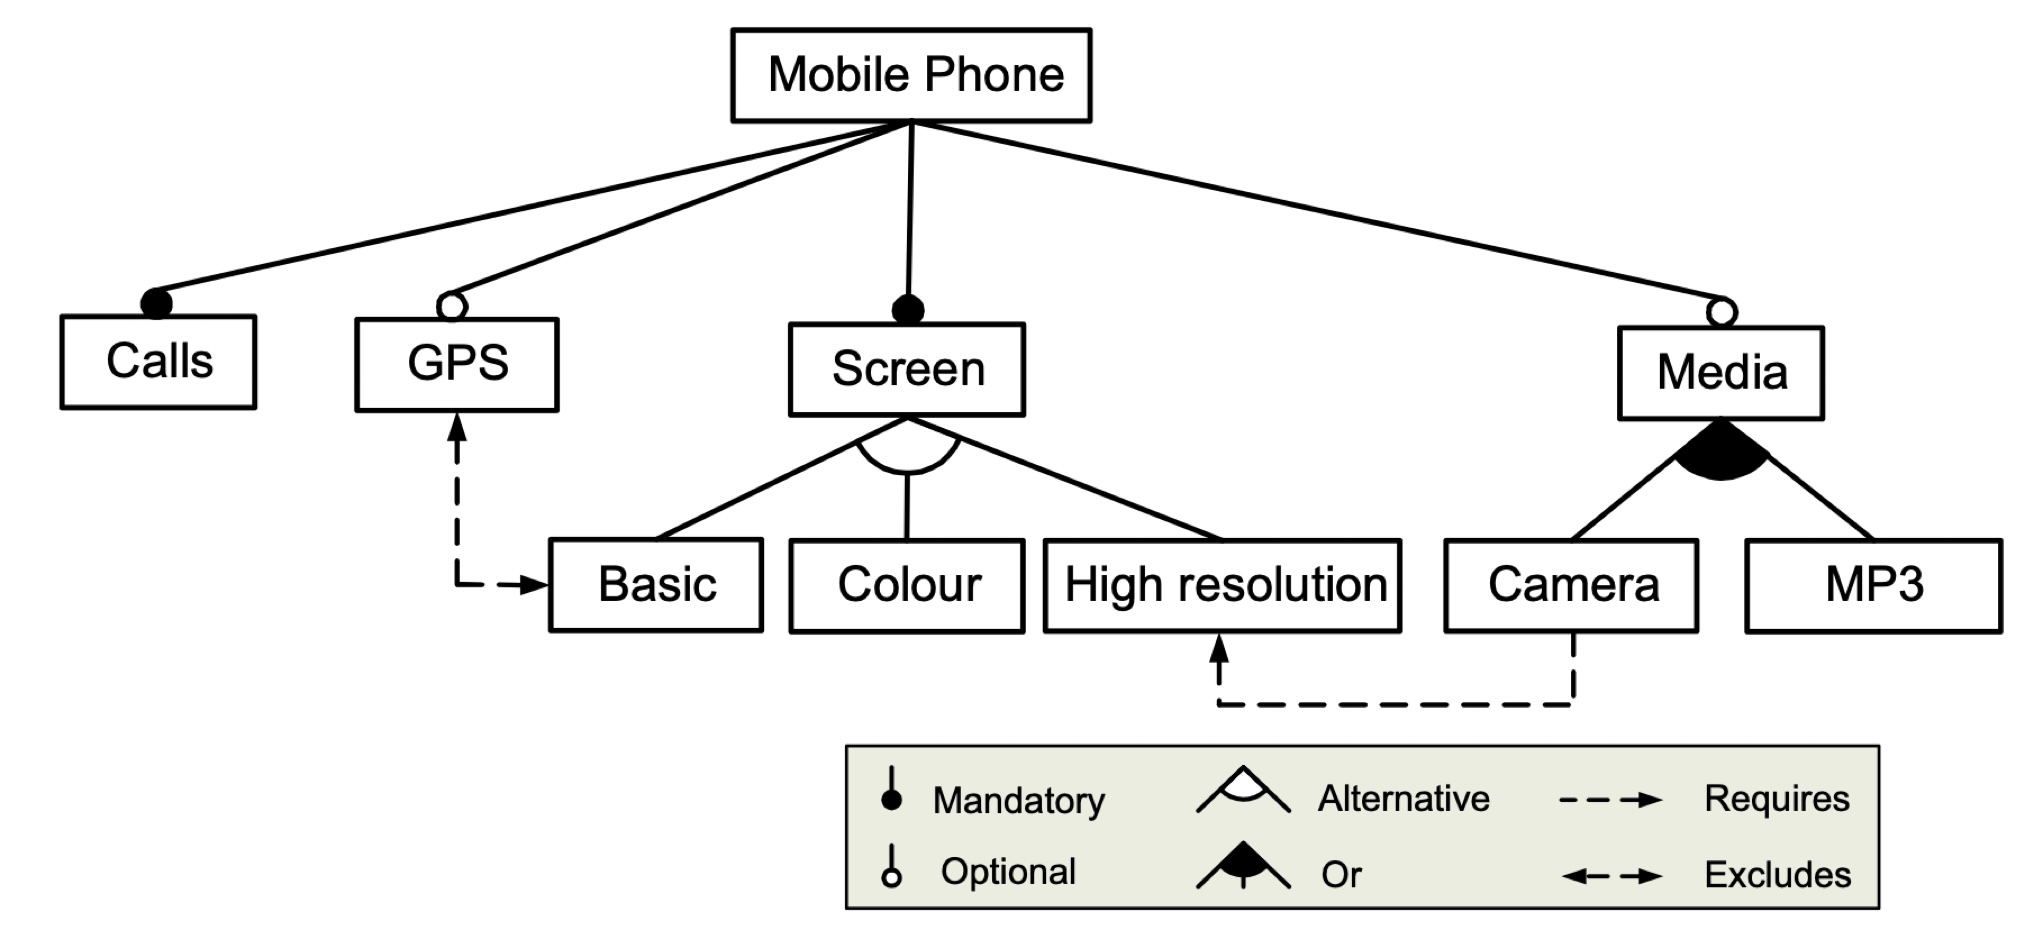


To check if this feature model is non-void we have to:

  1. Declare the Boolean variables that represent the features
  2. Add the formulas that specify the feature model constraints
  3. Check if the set of formulas is satisfiable


In [14]:
from z3 import *

Phone,Calls,GPS,Screen,Media,Basic,Colour,Highres,Camera,MP3 = Bools("Phone Calls GPS Screen Media Basic Colour Highres Camera MP3")
features = [Phone,Calls,GPS,Screen,Media,Basic,Colour,Highres,Camera,MP3]

s = Solver()

# Phone is a root reature
s.add(Phone)

# Calls is a mandatory sub-feature of Phone
s.add(Calls == Phone)

# GPS is an optional sub-feature of Phone
s.add(Implies(GPS,Phone))

# Screen is a mandatory sub-feature of Phone
s.add(Screen == Phone)

# Media is an optional sub-feature of Phone
s.add(Implies(Media,Phone))

# Basic, Colour, and Highres are xor sub-features of Screen
s.add(Or(Basic,Colour,Highres) == Screen)
s.add(Not(And(Basic,Colour)))
s.add(Not(And(Basic,Highres)))
s.add(Not(And(Colour,Highres)))

# Camera and MP3 are or sub-features of Media
s.add(Or(Camera,MP3) == Media)

# GPS excludes Basic
s.add(Not(And(GPS,Basic)))

# Camera requires Highres
s.add(Implies(Camera,Highres))


We can now invoke the SAT solver to solve the satisfiability problem, which in this case corresponds to the existence or not of products configured according to the above constraints.

In [15]:
if s.check() == sat:
  print("Feature model is non void.")
else:
  print("Feature model is void.")

Feature model is non void.


If a model does exist, we can fetch it from the solver and inspect it:

In [16]:
if s.check() == sat:
  m = s.model()
  print(m)


[Colour = False,
 Calls = True,
 GPS = False,
 Media = False,
 MP3 = False,
 Basic = True,
 Highres = False,
 Screen = True,
 Camera = False,
 Phone = True]


Alternatively, we can present the model in the form of a conjunctive formula:



In [17]:
if s.check() == sat:
  m = s.model()
  p = []
  for f in features:
    if is_true(m[f]):
      p.append(f)
    else:
      p.append(Not(f))
  print(And(p))

And(Phone,
    Calls,
    Not(GPS),
    Screen,
    Not(Media),
    Basic,
    Not(Colour),
    Not(Highres),
    Not(Camera),
    Not(MP3))


When exploring multiple related problems that share common constraints, the commands **push** and **pop** can be used to manage them efficiently. Each solver maintains a stack of assertions: the **push** command creates a new scope by saving the current stack state, while the **pop** command removes all assertions added since the corresponding **push**. The **check** method always operates on the assertions that are currently present in the solver’s stack.

To check if some feature is **dead** (i.e. not present in any configuration - if added to the above theory it breaks satisfiability) we should for each feature:

1.   Create a new frame in the solver stack of constraints
2.   Add a new constraint requiring that feature to be true
3.   Check if the new set of formulas is unsatisfiable
4.   If so, the feature is dead
5.   Pop up the new frame from the solver stack to remove the added constraint

In [21]:
for f in features:
  s.push()
  s.add(f)
  if s.check() == unsat:
    print("Feature " + f.decl().name() + "is dead!")
  s.pop()

To check if some feature is **core** (i.e. present in every configuration - it is a consequence of the above theory) we should for each feature:


1.   Create a new frame in the solver stack of constraints
2.   Add a new constraint requiring that feature to be false
3.   Check if the new set of formulas is unsatisfiable
4.   If so, the feature is core
5.   Pop up the new frame from the solver stack to remove the added constraint

In [19]:
for f in features:
  s.push()
  s.add(Not(f))
  if s.check() == unsat:
    print("Feature " + f.decl().name() + " is core!")
  s.pop()

Feature Phone is core!
Feature Calls is core!
Feature Screen is core!


In order to enumerate or count all possible products we should keep adding constraints that forbid possible products until the set of constraints is unsat.

In [20]:
s.push()
i = 0
while s.check() == sat:
  i += 1
  m = s.model()
  p = []
  for f in features:
    if is_true(m[f]):
      p.append(f)
      print(f.decl().name(),end=" ")
    else:
      p.append(Not(f))
  print()
  s.add(Not(And(p)))
print()
print("There are " + str(i) + " possible products!")
s.pop()

Phone Calls Screen Basic 
Phone Calls Screen Highres 
Phone Calls Screen Media Highres MP3 
Phone Calls Screen Media Highres Camera 
Phone Calls Screen Media Highres Camera MP3 
Phone Calls Screen Media Basic MP3 
Phone Calls Screen Colour 
Phone Calls GPS Screen Colour 
Phone Calls Screen Media Colour MP3 
Phone Calls GPS Screen Highres 
Phone Calls GPS Screen Media Highres MP3 
Phone Calls GPS Screen Media Highres Camera 
Phone Calls GPS Screen Media Highres Camera MP3 
Phone Calls GPS Screen Media Colour MP3 

There are 14 possible products!
